In [6]:
import os  # <--- Certifique-se de importar o 'os' no topo do arquivo!
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from Functions.Utils import *
from Functions.Graphs import *
from sklearn.metrics import root_mean_squared_error as rmse
import torch
import random
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
import math
from torch.utils.data import random_split

def definir_semente(semente=42):
    # 1. Python nativo
    random.seed(semente)
    os.environ['PYTHONHASHSEED'] = str(semente)
    
    # 2. NumPy
    np.random.seed(semente)
    
    # 3. PyTorch (CPU)
    torch.manual_seed(semente)
    
    # 4. PyTorch (Todas as GPUs disponíveis)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(semente)
        torch.cuda.manual_seed_all(semente) # Garante para múltiplos chips, se houver
        
        # 5. Configurações cruciais para determinismo do CUDA (cuDNN)
        # Força o cuDNN a usar sempre o mesmo algoritmo convolucional/recorrente
        torch.backends.cudnn.deterministic = True
        # Desativa a busca dinâmica pelo algoritmo cuDNN mais rápido (que pode variar a precisão)
        torch.backends.cudnn.benchmark = False

# Chamada da função (deve ser a primeira coisa a rodar no código)

def compute_track_features(df):
    # Map coordinates matrix
    waypoints = df[['x_coords', 'y_coords']].to_numpy()
    
    ct_errors = []
    heading_errors = []
    
    for i in range(len(df)):
        cur_x, cur_y = df.loc[i, 'x_coords'], df.loc[i, 'y_coords']
        cur_psi = np.radians(df.loc[i, 'psi'] % 360) # Normalize to radians
        
        # 1. Find closest point on reference track
        dists = np.linalg.norm(waypoints - np.array([cur_x, cur_y]), axis=1)
        closest_idx = np.argmin(dists)
        
        # 2. Compute cross-track error (distance)
        ct_errors.append(dists[closest_idx])
        
        # 3. Compute track heading angle at that segment
        next_idx = (closest_idx + 1) % len(df)
        dx = waypoints[next_idx][0] - waypoints[closest_idx][0]
        dy = waypoints[next_idx][1] - waypoints[closest_idx][1]
        track_psi = np.arctan2(dy, dx)
        
        # Heading error calculation
        psi_err = track_psi - cur_psi
        # Normalize error to [-pi, pi]
        psi_err = np.arctan2(np.sin(psi_err), np.cos(psi_err))
        heading_errors.append(psi_err)
        
    df['cross_track_error'] = ct_errors
    df['heading_error'] = heading_errors
    spd = df['speed'].values
    angle = df['angle'].values
    df = df.drop(columns=['speed','angle'])
    df = df.iloc[:-1,:].copy()
    df['speed_o'] = spd[:-1]
    df['angle'] = angle[1:]
    df['speed_f'] = spd[1:]

    return df

def criar_sequencias(X, y, time_steps=3):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

def criar_sequencias_futuras(X, y, time_steps_ahead=3):
    Xs, ys = [], []
    # O limite do loop garante que sempre existam amostras futuras suficientes de y
    for i in range(len(X) - time_steps_ahead):
        # Pega apenas o instante atual de X (mantendo a dimensão de sequência para a LSTM)
        Xs.append(X[i:i+1]) 
        
        # Coleta a janela futura de y (do instante i+1 até i+time_steps_ahead)
        janela_futura = y[i : i + time_steps_ahead]
        
        # Achata a janela para criar um vetor linear de alvos: 
        # [angulo_1, v_1, angulo_2, v_2, ..., angulo_N, v_N]
        ys.append(janela_futura.flatten())
        
    return np.array(Xs), np.array(ys)

path =  r'C:\Users\Claudio\Desktop\Python\ControlApplications\DyntheticDataset\RaceTrack.csv'
df = pd.read_csv(path)

df = compute_track_features(df)
df.head()

    

,time,x_coords,y_coords,psi,beta,cross_track_error,heading_error,speed_o,angle,speed_f
0,0.000000,72.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.325092
1,0.250468,72.004945,0.0,0.0,0.0,0.0,0.0,0.325092,0.0,0.629047
2,0.500936,72.022572,0.0,0.0,0.0,0.0,0.0,0.629047,0.0,0.913240
3,0.751404,72.052056,0.0,0.0,0.0,0.0,0.0,0.913240,0.0,1.178955
4,1.001873,72.092627,0.0,0.0,0.0,0.0,0.0,1.178955,0.0,1.427393


In [2]:
class PowerPredictorLSTM(nn.Module):

    def __init__(self, input_dim=3, hidden_dim=32, num_layers=2, output_dim=1):

        super(PowerPredictorLSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.linear = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):

        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.linear(out[:, -1, :])

        return out

In [3]:
path =  r'C:\Users\Claudio\Desktop\Python\ControlApplications\DyntheticDataset\RaceTrack.csv'
df = pd.read_csv(path)
df = compute_track_features(df)

X_raw2 = df[['psi', 'beta', 'cross_track_error', 'heading_error', 'speed_o']].values
y_raw2 = df[['angle', 'speed_f']].values

# IMPORTANTE: Usar transform(), NÃO fit_transform()
X_scaled2 = scaler_X.transform(X_raw2)
y_scaled2 = scaler_y.transform(y_raw2)

LOOKBACK = 1
# Reutilizamos a função de sequências para montar o histórico de 40 passos
X_seq2, y_seq2 = criar_sequencias(X_scaled2, y_scaled2, time_steps=LOOKBACK)

# Conversão para tensores do PyTorch
X_tensor2 = torch.tensor(X_seq2, dtype=torch.float32)
y_tensor2 = torch.tensor(y_seq2, dtype=torch.float32)

# --- 2. INFERÊNCIA COM O MODELO TREINADO ---
lstm.eval()  # Modo de avaliação (desativa dropout/batchnorm se houver)
with torch.no_grad():
    # Passa todo o bloco de teste para a GPU/Device
    X_tensor2 = X_tensor2.to(device)
    
    # Executa a predição com precisão mista para manter a performance da RTX 4060
    with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
        predicoes_normalizadas = lstm(X_tensor2).cpu().numpy()

# --- 3. DESNORMALIZAÇÃO DOS RESULTADOS ---
# Inverte a escala para voltarmos aos valores físicos reais
predicoes_reais = scaler_y.inverse_transform(predicoes_normalizadas)

# Como as primeiras 40 linhas foram usadas como "lookback", os valores reais correspondentes
# às predições começam a partir do índice 'LOOKBACK' do y_raw2 original

valores_reais = y_raw2[LOOKBACK:]

# Separando as colunas para facilitar a análise e plotagem
angulo_real = valores_reais[:, 0]
velocidade_real = valores_reais[:, 1]

angulo_predito = predicoes_reais[:, 0]
velocidade_predita = predicoes_reais[:, 1]

# --- 4. PLOTAGEM DA COMPARAÇÃO DIRETA ---
fig, ax = plt.subplots(2, 1, figsize=(14, 10))

# Subplot 1: Comparação de Ângulo de Esterço (Steering Angle)
ax[0].plot(angulo_real, label='Ângulo Real', color='black', alpha=0.8, linewidth=2)
ax[0].plot(angulo_predito, label='Ângulo Predito (LSTM)', color='crimson', linestyle='--', alpha=0.9)
ax[0].set_title('Comparação do Planner: Ângulo de Esterço ($\delta$) por Instante')
ax[0].set_ylabel('Ângulo / Comando')
ax[0].set_xlabel('Instantes de Tempo (Amostras)')
ax[0].legend(loc='upper right')
ax[0].grid(True, linestyle='--', alpha=0.5)

# Subplot 2: Comparação de Velocidade Futura (Speed)
ax[1].plot(velocidade_real, label='Velocidade Real', color='black', alpha=0.8, linewidth=2)
ax[1].plot(velocidade_predita, label='Velocidade Predita (LSTM)', color='darkcyan', linestyle='--', alpha=0.9)
ax[1].set_title('Comparação do Planner: Velocidade ($v$) por Instante')
ax[1].set_ylabel('Velocidade (m/s ou km/h)')
ax[1].set_xlabel('Instantes de Tempo (Amostras)')
ax[1].legend(loc='upper right')
ax[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# --- 5. MÉTRICAS DE ERRO COMPLEMENTARES ---
erro_angulo = np.mean((angulo_real - angulo_predito) ** 2)
erro_velocidade = np.mean((velocidade_real - velocidade_predita) ** 2)

print("-" * 50)
print(f"Métricas de Validação no Novo Dataset (df2):")
print(f"  MSE do Ângulo: {erro_angulo:.6f} | RMSE: {np.sqrt(erro_angulo):.6f}")
print(f"  MSE da Velocidade: {erro_velocidade:.6f} | RMSE: {np.sqrt(erro_velocidade):.6f}")
print("-" * 50)

NameError: name 'scaler_X' is not defined

Rodando no dispositivo: cpu

Iniciando o treinamento da LSTM na cpu...
Época [1/80] | Train Loss: 0.413373 | Val Loss: 0.364996
Época [5/80] | Train Loss: 0.091473 | Val Loss: 0.108111
Época [10/80] | Train Loss: 0.071384 | Val Loss: 0.069136
Época [15/80] | Train Loss: 0.044940 | Val Loss: 0.040118
Época [20/80] | Train Loss: 0.008384 | Val Loss: 0.007711
Época [25/80] | Train Loss: 0.003375 | Val Loss: 0.003774
Época [30/80] | Train Loss: 0.002909 | Val Loss: 0.003177
Época [35/80] | Train Loss: 0.002618 | Val Loss: 0.002824
Época [40/80] | Train Loss: 0.002470 | Val Loss: 0.002658
Época [45/80] | Train Loss: 0.002312 | Val Loss: 0.002529
Época [50/80] | Train Loss: 0.002226 | Val Loss: 0.002483
Época [55/80] | Train Loss: 0.002201 | Val Loss: 0.002385
Época [60/80] | Train Loss: 0.002148 | Val Loss: 0.002368
Época [65/80] | Train Loss: 0.002114 | Val Loss: 0.002311
Época [70/80] | Train Loss: 0.002044 | Val Loss: 0.002289
Época [75/80] | Train Loss: 0.002070 | Val Loss: 0.002216
Épo

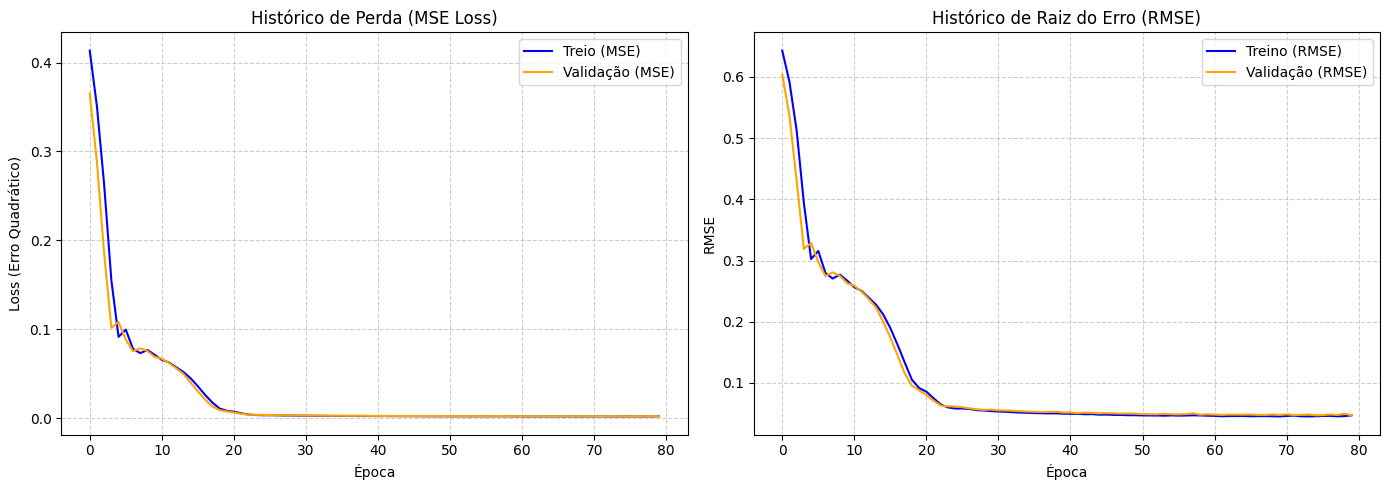

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Rodando no dispositivo: {device}")

path =  r'C:\Users\Claudio\Desktop\Python\ControlApplications\DyntheticDataset\RaceTrack.csv'
df = pd.read_csv(path)
df = compute_track_features(df)

X_raw = df[['psi', 'beta', 'cross_track_error', 'heading_error', 'speed_o']].values
y_raw = df[['angle', 'speed_f']].values

# --- 3. Pré-processamento, Normalização e Divisão do Dataset ---
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X_raw)
y_scaled = scaler_y.fit_transform(y_raw)

def criar_sequencias(X, y, time_steps=3):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

AHEAD = 5
SEMENTE = 41
definir_semente(SEMENTE)
X_seq, y_seq = criar_sequencias_futuras(X_scaled, y_scaled, time_steps_ahead=AHEAD)

X_tensor = torch.tensor(X_seq, dtype=torch.float32)
y_tensor = torch.tensor(y_seq, dtype=torch.float32)

dataset_completo = TensorDataset(X_tensor, y_tensor)

g_pytorch = torch.Generator()
g_pytorch.manual_seed(SEMENTE)

# DIVISÃO DE TREINO E VALIDAÇÃO (80% / 20%)
val_size = int(len(dataset_completo) * 0.25)
train_size = len(dataset_completo) - val_size
dataset_train, dataset_val = random_split(dataset_completo, [train_size, val_size],generator=g_pytorch)

dataloader_train = DataLoader(dataset_train, batch_size=128, shuffle=True, pin_memory=torch.cuda.is_available())
dataloader_val = DataLoader(dataset_val, batch_size=128, shuffle=False, pin_memory=torch.cuda.is_available())

# --- 4. Construção da Arquitetura LSTM ---
# (Mantenha sua classe PowerPredictorLSTM exatamente como está)

lstm = PowerPredictorLSTM(input_dim=X_tensor.shape[2], hidden_dim=32, num_layers=2, output_dim=y_tensor.shape[1]).to(device)

# --- 5. Critério de Erro e Otimizador ---
criterion = nn.MSELoss() 
optimizer = torch.optim.Adam(lstm.parameters(), lr=0.005)

# --- 6. Loop de Treinamento e Validação com Histórico ---
print(f"\nIniciando o treinamento da LSTM na {device}...")

scaler = torch.amp.GradScaler('cuda', enabled=torch.cuda.is_available())

# Listas para simular o "history" do Keras
history = {
    'loss': [],
    'val_loss': [],
    'rmse': [],
    'val_rmse': []
}

num_epochs = 80

for epoch in range(num_epochs):
    # FASE DE TREINO
    lstm.train()
    epoch_train_loss = 0.0
    for batch_X, batch_y in dataloader_train:
        batch_X = batch_X.to(device, non_blocking=True)
        batch_y = batch_y.to(device, non_blocking=True)
        
        optimizer.zero_grad(set_to_none=True)
        
        with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
            predictions = lstm(batch_X)
            loss = criterion(predictions, batch_y)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        epoch_train_loss += loss.item() * batch_X.size(0)
        
    train_loss_medio = epoch_train_loss / len(dataloader_train.dataset)
    train_rmse_medio = math.sqrt(train_loss_medio)
    
    # FASE DE VALIDAÇÃO
    lstm.eval()
    epoch_val_loss = 0.0
    with torch.no_grad():
        for batch_X, batch_y in dataloader_val:
            batch_X = batch_X.to(device, non_blocking=True)
            batch_y = batch_y.to(device, non_blocking=True)
            
            with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
                predictions = lstm(batch_X)
                loss = criterion(predictions, batch_y)
                
            epoch_val_loss += loss.item() * batch_X.size(0)
            
    val_loss_medio = epoch_val_loss / len(dataloader_val.dataset)
    val_rmse_medio = math.sqrt(val_loss_medio)
    
    # Salva as métricas no dicionário histórico
    history['loss'].append(train_loss_medio)
    history['val_loss'].append(val_loss_medio)
    history['rmse'].append(train_rmse_medio)
    history['val_rmse'].append(val_rmse_medio)
    
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Época [{epoch+1}/{num_epochs}] | Train Loss: {train_loss_medio:.6f} | Val Loss: {val_loss_medio:.6f}")

# --- NOVA FUNÇÃO DE PLOT COMPATÍVEL COM PYTORCH ---
def plot_pytorch_history(history_dict):
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    
    # Gráfico 1: MSE Loss
    ax[0].plot(history_dict['loss'], label='Treio (MSE)', color='blue')
    ax[0].plot(history_dict['val_loss'], label='Validação (MSE)', color='orange')
    ax[0].set_title('Histórico de Perda (MSE Loss)')
    ax[0].set_ylabel('Loss (Erro Quadrático)')
    ax[0].set_xlabel('Época')
    ax[0].legend(loc='upper right')
    ax[0].grid(True, linestyle='--', alpha=0.6)
    
    # Gráfico 2: RMSE
    ax[1].plot(history_dict['rmse'], label='Treino (RMSE)', color='blue')
    ax[1].plot(history_dict['val_rmse'], label='Validação (RMSE)', color='orange')
    ax[1].set_title('Histórico de Raiz do Erro (RMSE)')
    ax[1].set_ylabel('RMSE')
    ax[1].set_xlabel('Época')
    ax[1].legend(loc='upper right')
    ax[1].grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

# Chama a função para renderizar o gráfico
plot_pytorch_history(history)

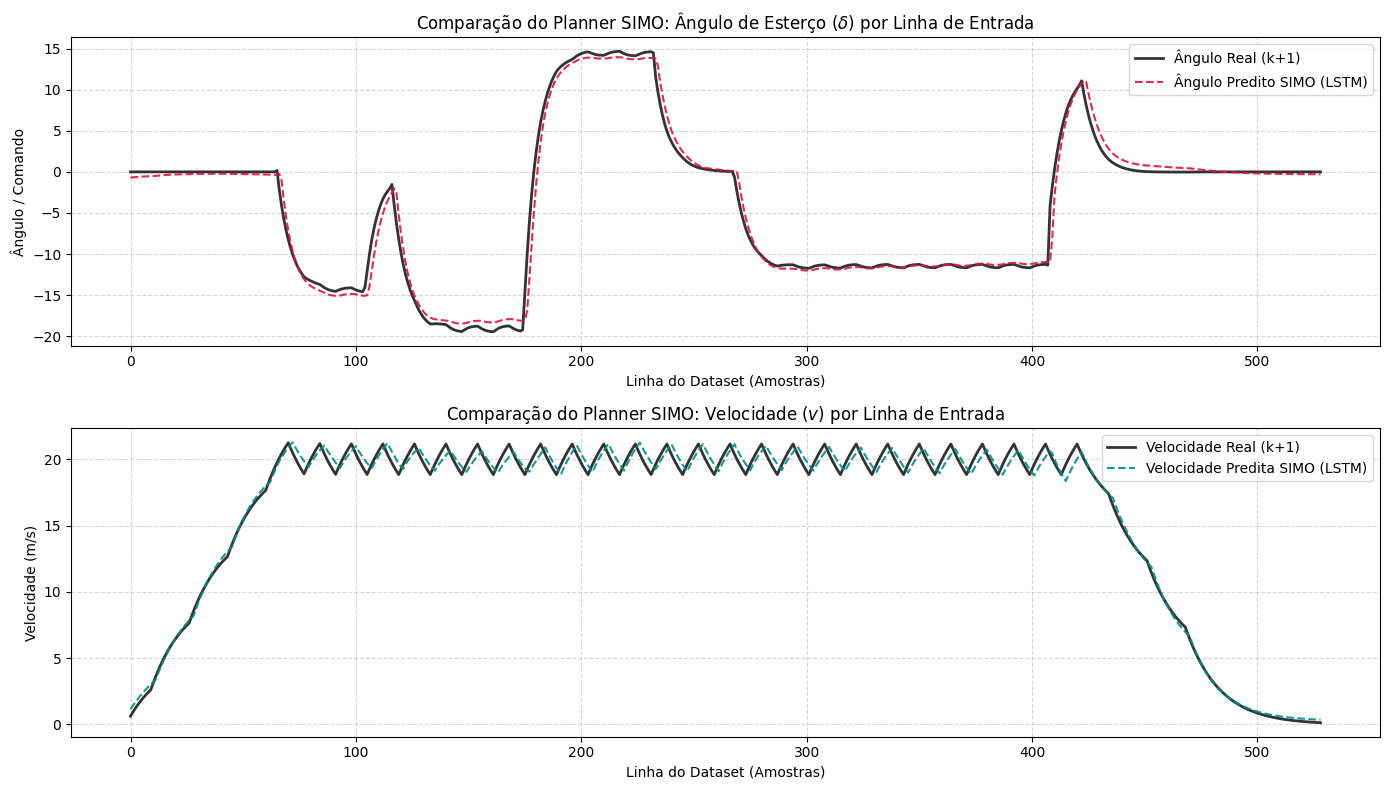

--------------------------------------------------
Métricas de Validação Linearizada (Passo k+1) no df2:
  MSE do Ângulo: 1.305739 | RMSE: 1.142689
  MSE da Velocidade: 0.257516 | RMSE: 0.507460
--------------------------------------------------


In [5]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# --- 1. CARREGAMENTO E NORMALIZAÇÃO DOS DADOS ---
path = r'C:\Users\Claudio\Desktop\Python\ControlApplications\DyntheticDataset\RaceTrack.csv'
df2 = pd.read_csv(path)
df2 = compute_track_features(df2)

X_raw2 = df2[['psi', 'beta', 'cross_track_error', 'heading_error', 'speed_o']].values
y_raw2 = df2[['angle', 'speed_f']].values

# Usando rigorosamente o transform() dos scalers originais do treino
X_scaled2 = scaler_X.transform(X_raw2)
y_scaled2 = scaler_y.transform(y_raw2)

# --- 2. CONFIGURAÇÃO DA ENTRADA SIMO (SINGLE-INPUT) ---
# Geramos as sequências onde cada amostra de X possui shape [1, 5]
TIME_STEPS_AHEAD = 5 # Definição original do seu horizonte de predição

X_seq2, y_seq2 = criar_sequencias_futuras(X_scaled2, y_scaled2, time_steps_ahead=TIME_STEPS_AHEAD)
X_tensor2 = torch.tensor(X_seq2, dtype=torch.float32)

# --- 3. INFERÊNCIA MULTI-PASSO EM LOTE (BATCH) ---
lstm.eval()
with torch.no_grad():
    X_tensor2 = X_tensor2.to(device)
    with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
        # predicoes_normalizadas terá o formato [N_amostras, 6]
        predicoes_normalizadas = lstm(X_tensor2).cpu().numpy()

# --- 4. EXTENSÃO E DESNORMALIZAÇÃO VETORIAL ---
# Para comparar linha por linha, vamos extrair apenas o primeiro passo previsto (k+1) 
# de cada uma das predições da rede.
# Reorganiza de [N, 6] para [N, TIME_STEPS_AHEAD, 2] -> [N, 3, 2]
pred_remodelado = predicoes_normalizadas.reshape(-1, TIME_STEPS_AHEAD, 2)
real_remodelado = y_seq2.reshape(-1, TIME_STEPS_AHEAD, 2)
# Coleta apenas o passo [:, 0, :] que representa o instante k+1 de todas as linhas
pred_passo_k1_normalizado = pred_remodelado[:, 1, :]

yP = [pred_remodelado[:, j, :] for j in range(pred_remodelado.shape[1])]

yR = [real_remodelado[:, j, :] for j in range(pred_remodelado.shape[1])]

for j in range(pred_remodelado.shape[1]):
    yP[j] = scaler_y.inverse_transform(yP[j])
    yR[j] = scaler_y.inverse_transform(yR[j])

# Agora sim, desnormalizamos usando o formato nativo de 2 colunas do scaler_y
predicoes_reais = scaler_y.inverse_transform(pred_passo_k1_normalizado)

# Como criar_sequencias_futuras descarta as últimas amostras (pelo limite do horizonte),
# os valores reais de y correspondentes a k+1 começam exatamente a partir do índice 1 de y_raw2
valores_reais = y_raw2[1 : 1 + len(predicoes_reais)]


# Separando as variáveis para análise
angulo_real = valores_reais[:, 0]
velocidade_real = valores_reais[:, 1]

angulo_predito = predicoes_reais[:, 0]
velocidade_predita = predicoes_reais[:, 1]

# --- 5. PLOTAGEM DA COMPARAÇÃO DIRETA ---
fig, ax = plt.subplots(2, 1, figsize=(14, 8))

# Subplot 1: Ângulo de Esterço
ax[0].plot(angulo_real, label='Ângulo Real (k+1)', color='black', alpha=0.8, linewidth=2)
ax[0].plot(angulo_predito, label='Ângulo Predito SIMO (LSTM)', color='crimson', linestyle='--', alpha=0.9)
ax[0].set_title('Comparação do Planner SIMO: Ângulo de Esterço ($\delta$) por Linha de Entrada')
ax[0].set_ylabel('Ângulo / Comando')
ax[0].set_xlabel('Linha do Dataset (Amostras)')
ax[0].legend(loc='upper right')
ax[0].grid(True, linestyle='--', alpha=0.5)

# Subplot 2: Velocidade Futura
ax[1].plot(velocidade_real, label='Velocidade Real (k+1)', color='black', alpha=0.8, linewidth=2)
ax[1].plot(velocidade_predita, label='Velocidade Predita SIMO (LSTM)', color='darkcyan', linestyle='--', alpha=0.9)
ax[1].set_title('Comparação do Planner SIMO: Velocidade ($v$) por Linha de Entrada')
ax[1].set_ylabel('Velocidade (m/s)')
ax[1].set_xlabel('Linha do Dataset (Amostras)')
ax[1].legend(loc='upper right')
ax[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# --- 6. CÁLCULO DAS MÉTRICAS REAIS ---
erro_angulo = np.mean((angulo_real - angulo_predito) ** 2)
erro_velocidade = np.mean((velocidade_real - velocidade_predita) ** 2)

print("-" * 50)
print(f"Métricas de Validação Linearizada (Passo k+1) no df2:")
print(f"  MSE do Ângulo: {erro_angulo:.6f} | RMSE: {np.sqrt(erro_angulo):.6f}")
print(f"  MSE da Velocidade: {erro_velocidade:.6f} | RMSE: {np.sqrt(erro_velocidade):.6f}")
print("-" * 50)

In [5]:
yR
aP,aR = [],[]
sP,sR = [],[]
for i in range(TIME_STEPS_AHEAD):
    aP.append(yP[i].T[0])
    aR.append(yR[i].T[0])
    sR.append(yR[i].T[1])
    sP.append(yP[i].T[1])

aPt = np.array(aP).T
aRt = np.array(aR).T
sRt = np.array(sR).T
sPt = np.array(sP).T

In [6]:
i = 2
PlotSeriesPLY(ySeries=[sR[i],sP[i]])

In [8]:
i = 100
PlotSeriesPLY(ySeries=[aRt[i],aPt[i]])

In [363]:
i = 30
PlotSeriesPLY(ySeries=[sRt[i],sPt[i]])